# Sun Diagnostic Visualization

Split from `diagnostic_sun.ipynb`: shared setup cells followed by data-quality and inspection plots.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import get_sun
from astropy.time import Time

from utils.constants import (
    F_S_HZ,
    N_FFT,
    LO1_HZ,
    LO2_HZ,
    IF1_BPF_CENTER_HZ,
    IF1_BPF_HALF_BW_HZ,
    PLOT_BAND_GHZ,
    F_RF0_HZ,
)

from utils.chips import segment_captures_by_gap, sort_captures_by_mid_unix
from utils.dc import local_real_dc_correction
from utils.plotter import (
    plot_capture_timeline_and_gaps,
    plot_channel_time_series,
    plot_example_spectrum,
    plot_unwrapped_phase_vs_ha_time,
    plot_waterfall_suite,
)


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data/lab03/m1_calibration')

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]

f0 = files[0]
N_CH = int(f0['corr'].shape[0])
DF_HZ = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

print(f'Loaded {len(files)} captures  |  '
      f'{F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  '
      f'{DF_HZ/1e3:.1f} kHz/ch')
print(f'Analysis band : {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

all_amp                  = np.array([np.abs(f['corr']) for f in files]).astype(float)
all_amp[:, BAD_CHANNELS] = np.nan

print(f'Masked : {BAD_CHANNELS}  '
      f'({[f"{F_SKY_GHZ[k]:.4f} GHz" for k in BAD_CHANNELS]})')

# ── Normalise ─────────────────────────────────────────────────────────────
AMP_PEAK = np.nanmax(all_amp)
print(f'Peak   : {AMP_PEAK:.4g}')


Loaded 17 captures  |  10.2900 -- 10.5398 GHz  |  244.1 kHz/ch
Analysis band : 10.415 -- 10.485 GHz
Masked : [0, 256, 512, 768]  (['10.2900 GHz', '10.3525 GHz', '10.4150 GHz', '10.4775 GHz'])
Peak   : 0.7947


In [3]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Sun's RA changes ~1°/day, so it must be recomputed per capture.
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    """Sun's J2000 RA in degrees at the given unix time."""
    return get_sun(Time(unix_t, format='unix')).ra.deg

sorted_caps = sort_captures_by_mid_unix(files, paths)
files_s   = sorted_caps.files_sorted
paths_s   = sorted_caps.paths_sorted
unix_sort = sorted_caps.unix_sorted
N_cap     = len(files_s)

lst_arr     = np.array([_lst_deg(t)    for t in unix_sort])
sun_ra_arr  = np.array([_sun_ra_deg(t) for t in unix_sort])
ha_deg      = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

chip_info = segment_captures_by_gap(files_s, unix_sort, ha_deg)
chip_slices = chip_info.chip_slices
files_chips = chip_info.files_chips
unix_chips  = chip_info.unix_chips
ha_chips    = chip_info.ha_chips
N_caps      = chip_info.N_caps
cap_chip    = chip_info.cap_chip
_gaps       = chip_info.gap_s

print(f'Nominal inter-capture gap: {chip_info.nominal_gap_sec:.3f} s')
print(f'Chip split threshold: {chip_info.split_gap_threshold_sec:.3f} s')
if chip_info.gap_break_indices.size:
    for break_idx, gap_s in zip(chip_info.gap_break_indices, chip_info.gap_break_values_sec):
        print(f'Break at index {break_idx-1}→{break_idx}: {gap_s:.1f} s  ({gap_s/60:.1f} min)')
else:
    print('No chip breaks detected.')

for chip_idx, (n_cap_chip, ha_chip) in enumerate(zip(N_caps, ha_chips)):
    print(f'Chip {chip_idx}: {n_cap_chip} captures,  HA {ha_chip.min():.2f}° → {ha_chip.max():.2f}°')

# Peak channel within PLOT_BAND_GHZ (excluding artifact channels)
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak   = np.array([f['corr'][k_peak] for f in files_s])
amp_peak   = np.abs(vis_peak) / AMP_PEAK
phase_peak = np.rad2deg(np.angle(vis_peak))

print(f'Sun RA   : {sun_ra_arr.min():.4f} -- {sun_ra_arr.max():.4f} deg  '
      f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f} deg)')
print(f'HA range : {ha_deg.min():.2f}° -> {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
print(f'Phase        : mean={phase_peak.mean():.1f}°,  std={phase_peak.std():.1f}°')


Nominal inter-capture gap: 0.247 s
Chip split threshold: 5.000 s
No chip breaks detected.
Chip 0: 17 captures,  HA 178.68° → 179.91°
Sun RA   : 359.4116 -- 359.4147 deg  (span 0.0031 deg)
HA range : 178.68° -> 179.91°  (1.22° span)
Peak channel : k=574,  f_sky=10.4301 GHz
Amp  (norm)  : mean=0.979,  std=0.012
Phase        : mean=178.4°,  std=0.4°


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_68689/3265175641.py:53: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


Live integration time: 5.08 min
Total wall-clock span : 5.18 min
Duty cycle            : 98.15%


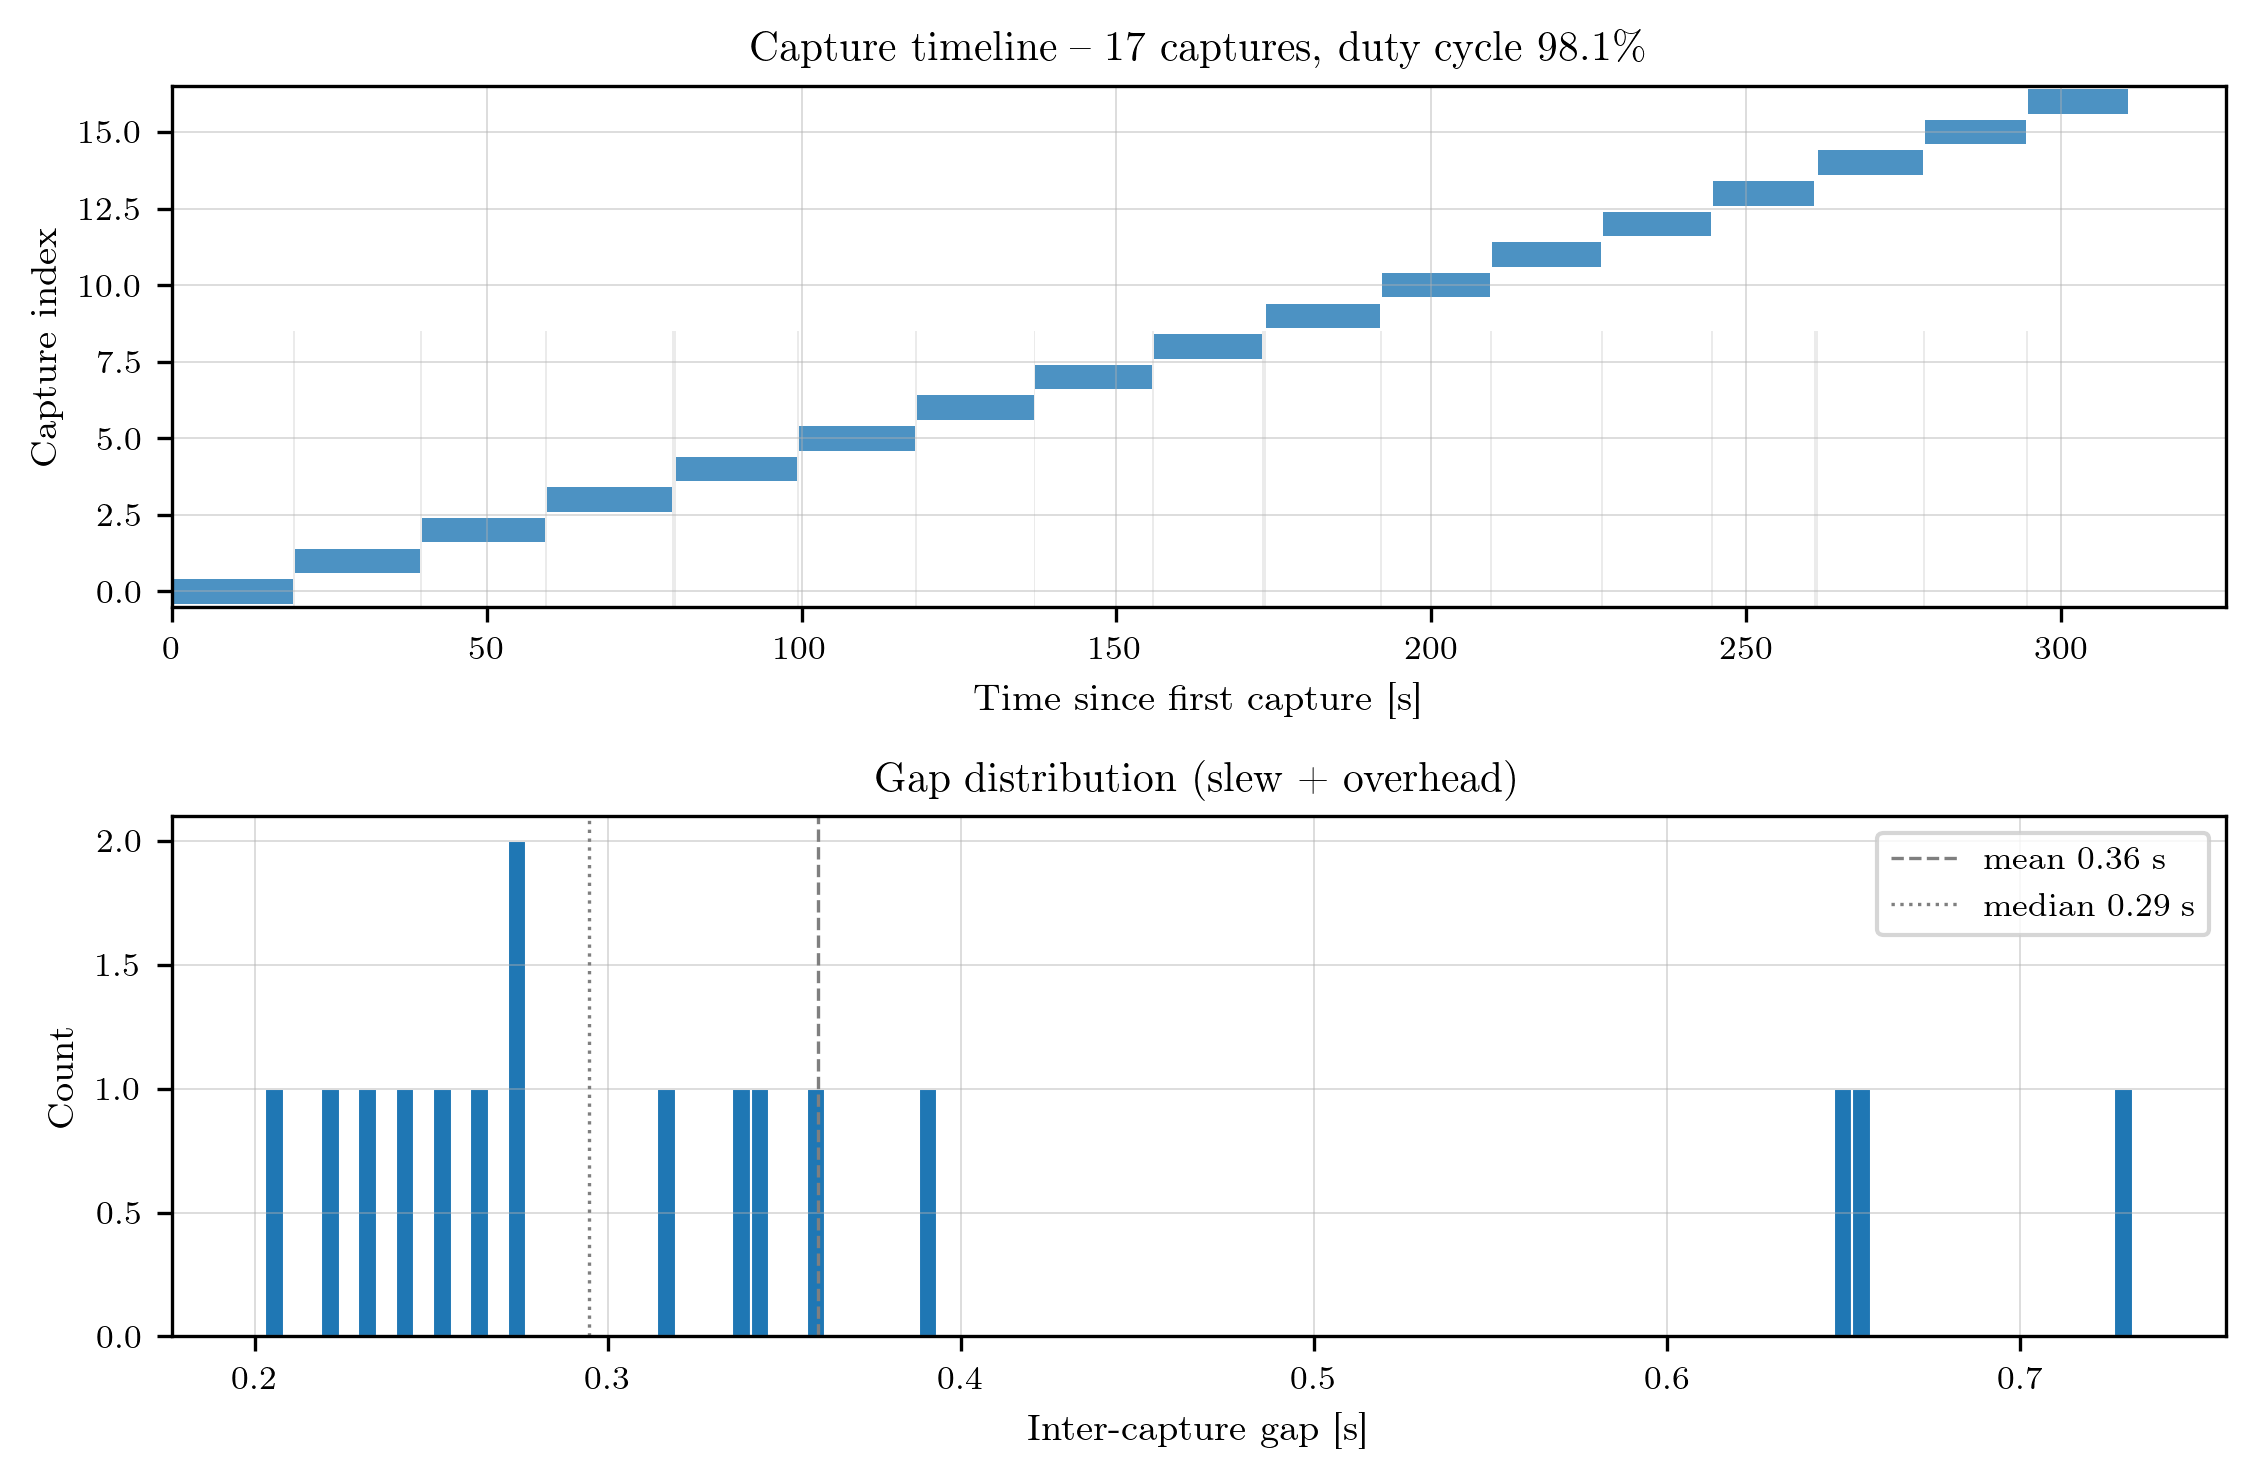

In [4]:
# ---------------------------------------------------------------------------
# Capture timeline and gap statistics
# ---------------------------------------------------------------------------

capture_start_unix = np.array([float(f['unix_time_start']) for f in files_s], dtype=float)
capture_end_unix = np.array([float(f['unix_time_end']) for f in files_s], dtype=float)
t0_unix = capture_start_unix[0]
capture_start_s = capture_start_unix - t0_unix
capture_end_s = capture_end_unix - t0_unix
capture_duration_s = capture_end_unix - capture_start_unix
gap_s = capture_start_unix[1:] - capture_end_unix[:-1]
span_s = capture_end_unix[-1] - capture_start_unix[0]
duty_cycle_pct = 100.0 * capture_duration_s.sum() / span_s if span_s > 0 else 100.0

print(f'Live integration time: {capture_duration_s.sum()/60:.2f} min')
print(f'Total wall-clock span : {span_s/60:.2f} min')
print(f'Duty cycle            : {duty_cycle_pct:.2f}%')

fig, axes = plot_capture_timeline_and_gaps(
    capture_start_s=capture_start_s,
    capture_end_s=capture_end_s,
    capture_count=N_cap,
    duty_cycle_pct=duty_cycle_pct,
    gap_s=gap_s,
)
plt.show()


In [5]:
# ---------------------------------------------------------------------------
# Local DC correction per chip — rolling real-median pedestal subtraction.
# Each chip is corrected independently, and the local window never crosses
# chip boundaries.
# corr_dc_chips[c] : (N_caps[c], N_CH)  locally DC-corrected complex visibility
# corr_dc           : (N_cap, N_CH)     full sequence (for non-gap-sensitive cells)
# ---------------------------------------------------------------------------

NOMINAL_FRINGE_PERIOD_SEC = 40.0
LOCAL_DC_PERIODS = 2.5
LOCAL_DC_WINDOW_SEC = NOMINAL_FRINGE_PERIOD_SEC * LOCAL_DC_PERIODS

dc_result = local_real_dc_correction(
    files_chips=files_chips,
    unix_chips=unix_chips,
    bad_channels=BAD_CHANNELS,
    nominal_fringe_period_sec=NOMINAL_FRINGE_PERIOD_SEC,
    window_periods=LOCAL_DC_PERIODS,
)

corr_dc_chips = dc_result.corr_dc_chips
corr_dc = dc_result.corr_dc
real_dc_offset_chips = dc_result.real_offset_chips

print(f'Local DC target window: {dc_result.window_sec:.1f} s')
for chip_idx, (cadence_sec, window_caps) in enumerate(
    zip(dc_result.median_cadence_sec_chips, dc_result.window_caps_chips)
):
    cadence_label = f'{cadence_sec:.2f} s' if np.isfinite(cadence_sec) else 'single capture'
    print(f'Chip {chip_idx}: median cadence {cadence_label},  local window {window_caps} captures')


Local DC target window: 100.0 s
Chip 0: median cadence 18.23 s,  local window 5 captures


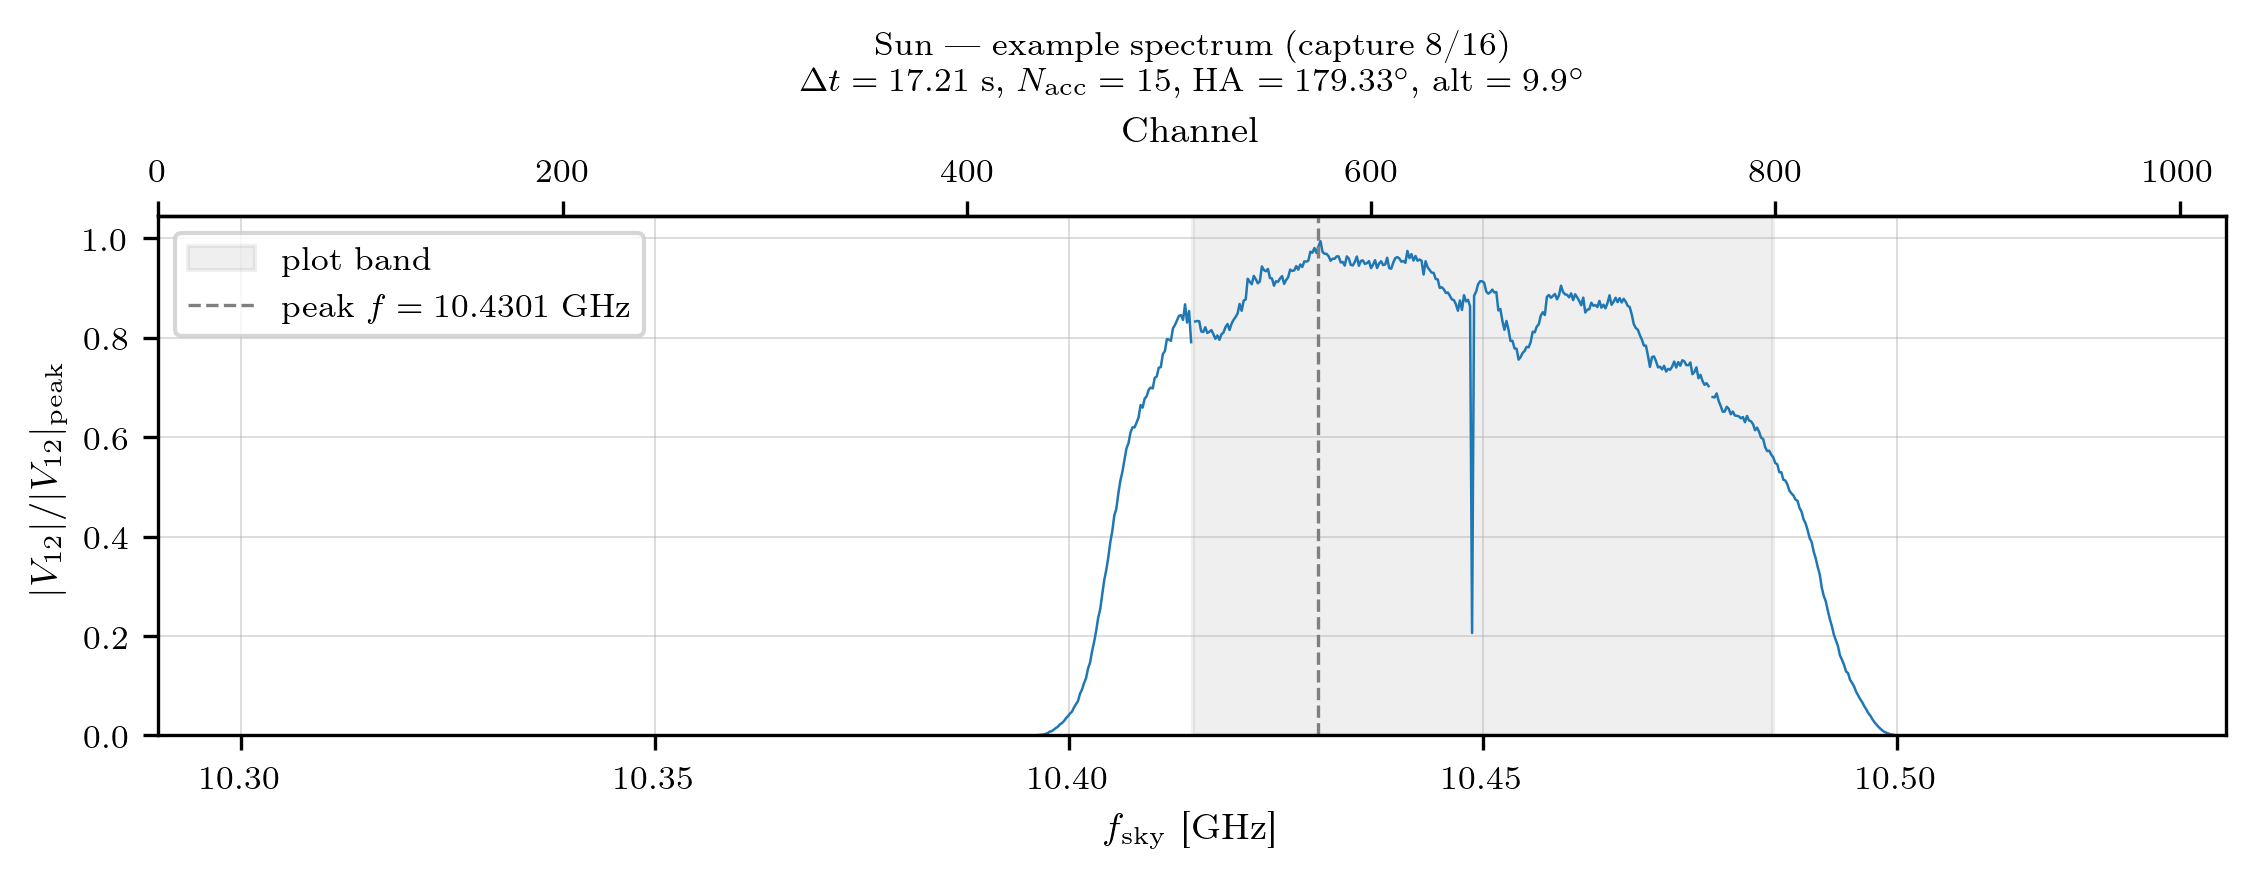

In [6]:
# ---------------------------------------------------------------------------
# Example spectrum — median capture
# ---------------------------------------------------------------------------

i_med    = len(files_s) // 2
f_ex     = files_s[i_med]
amp_ex   = np.abs(f_ex['corr']).astype(float) / AMP_PEAK
amp_ex[BAD_CHANNELS] = np.nan

integ_s  = float(f_ex['unix_time_end']) - float(f_ex['unix_time_start'])
n_acc_ex = int(f_ex['n_acc'])
alt_ex   = float(f_ex['alt_deg']) if 'alt_deg' in f_ex else float('nan')
ha_ex    = ha_deg[i_med]

fig, ax = plot_example_spectrum(
    f_sky_ghz=F_SKY_GHZ,
    amp_norm=amp_ex,
    plot_band_ghz=PLOT_BAND_GHZ,
    peak_freq_ghz=F_PEAK_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
    capture_index=i_med,
    capture_count=len(files_s),
    integration_s=integ_s,
    n_acc=n_acc_ex,
    ha_deg=ha_ex,
    alt_deg=alt_ex,
)
plt.show()


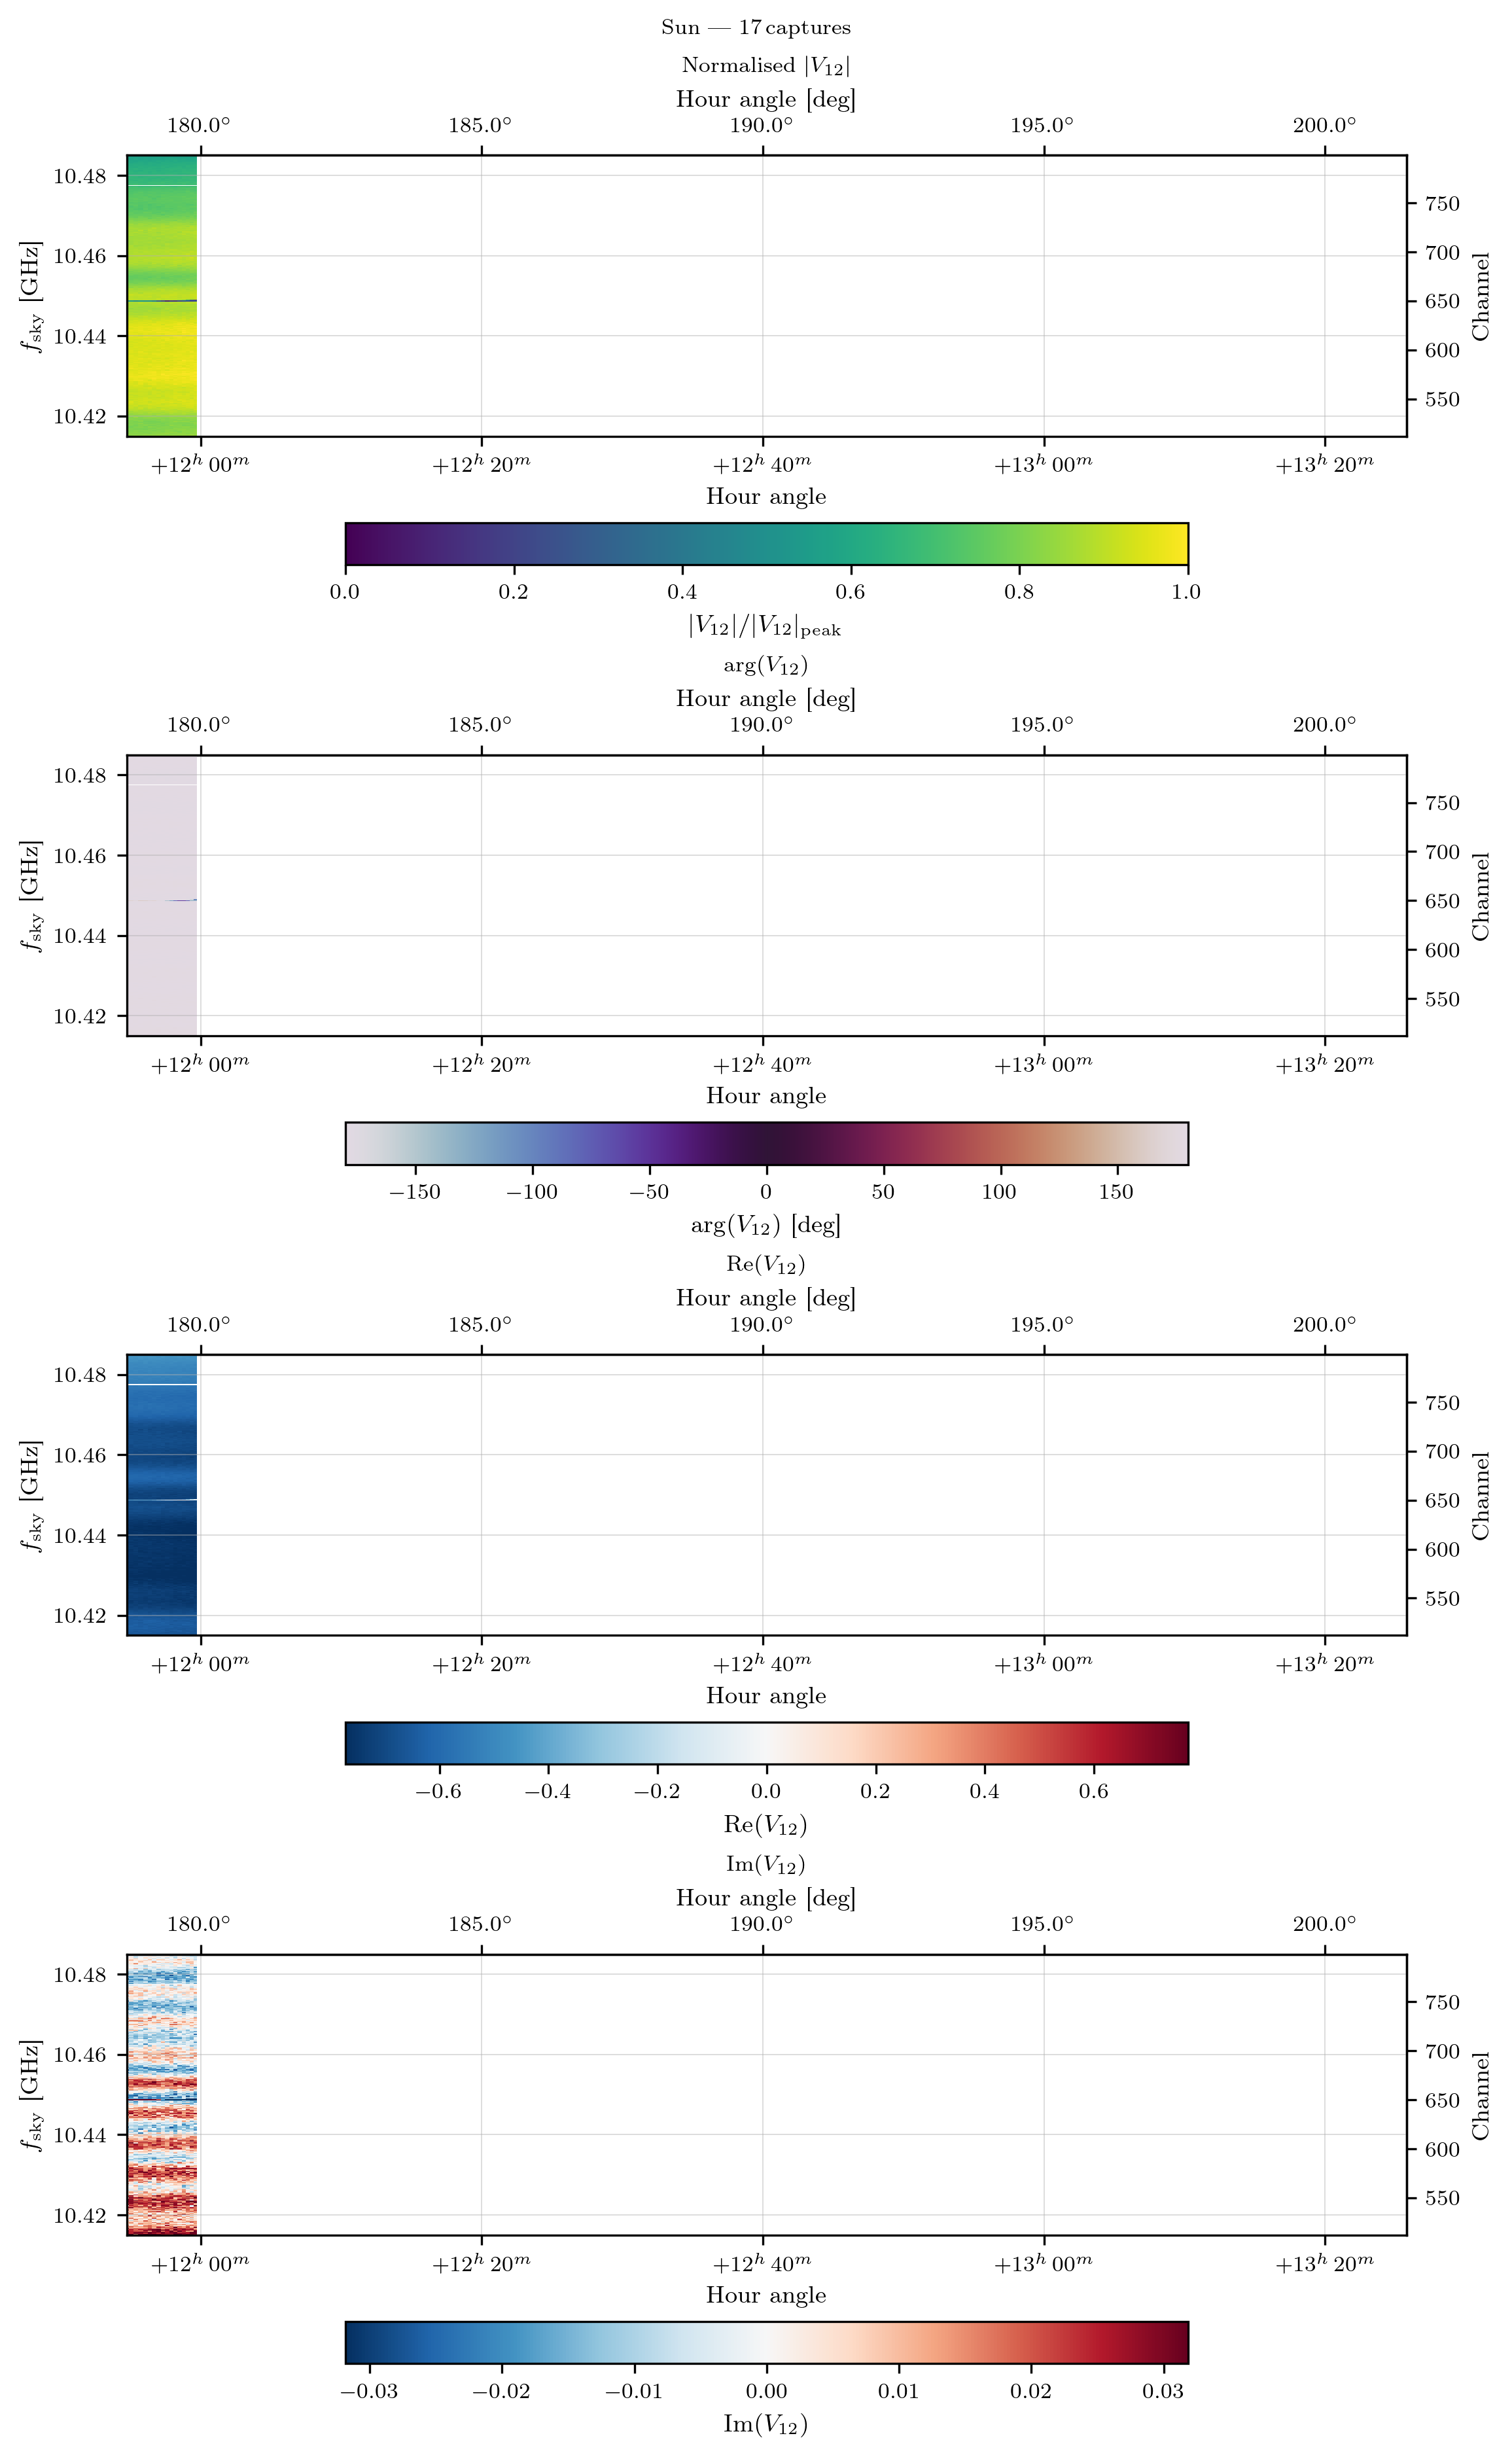

In [7]:
# ---------------------------------------------------------------------------
# Waterfalls: normalised amplitude, arg(V_12), Re(V_12), Im(V_12)  — f_sky vs hour angle
# ---------------------------------------------------------------------------

corr_matrix = np.array([f['corr'].astype(complex) for f in files_s])
corr_matrix[:, BAD_CHANNELS] = np.nan

amp_matrix = np.abs(corr_matrix) / AMP_PEAK
phase_matrix = np.rad2deg(np.angle(corr_matrix))
real_matrix = corr_matrix.real
imag_matrix = corr_matrix.imag
real_vabs = np.nanpercentile(np.abs(real_matrix), 99)
imag_vabs = np.nanpercentile(np.abs(imag_matrix), 99)

fig, axes = plot_waterfall_suite(
    f_sky_ghz=F_SKY_GHZ,
    ha_deg=ha_deg,
    quantity_matrices=[amp_matrix, phase_matrix, real_matrix, imag_matrix],
    quantity_titles=[
        r'Normalised $|V_{12}|$',
        r'$\arg(V_{12})$',
        r'$\mathrm{Re}(V_{12})$',
        r'$\mathrm{Im}(V_{12})$',
    ],
    cbar_labels=[
        r'$|V_{12}| / |V_{12}|_{\rm peak}$',
        r'$\arg(V_{12})$ [deg]',
        r'$\mathrm{Re}(V_{12})$',
        r'$\mathrm{Im}(V_{12})$',
    ],
    cmap_names=['viridis', 'twilight', 'RdBu_r', 'RdBu_r'],
    vmins=[0, -180, -real_vabs, -imag_vabs],
    vmaxs=[1, 180, real_vabs, imag_vabs],
    plot_band_ghz=PLOT_BAND_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
    title=rf'Sun --- {len(files_s)}\,captures',
)
plt.show()


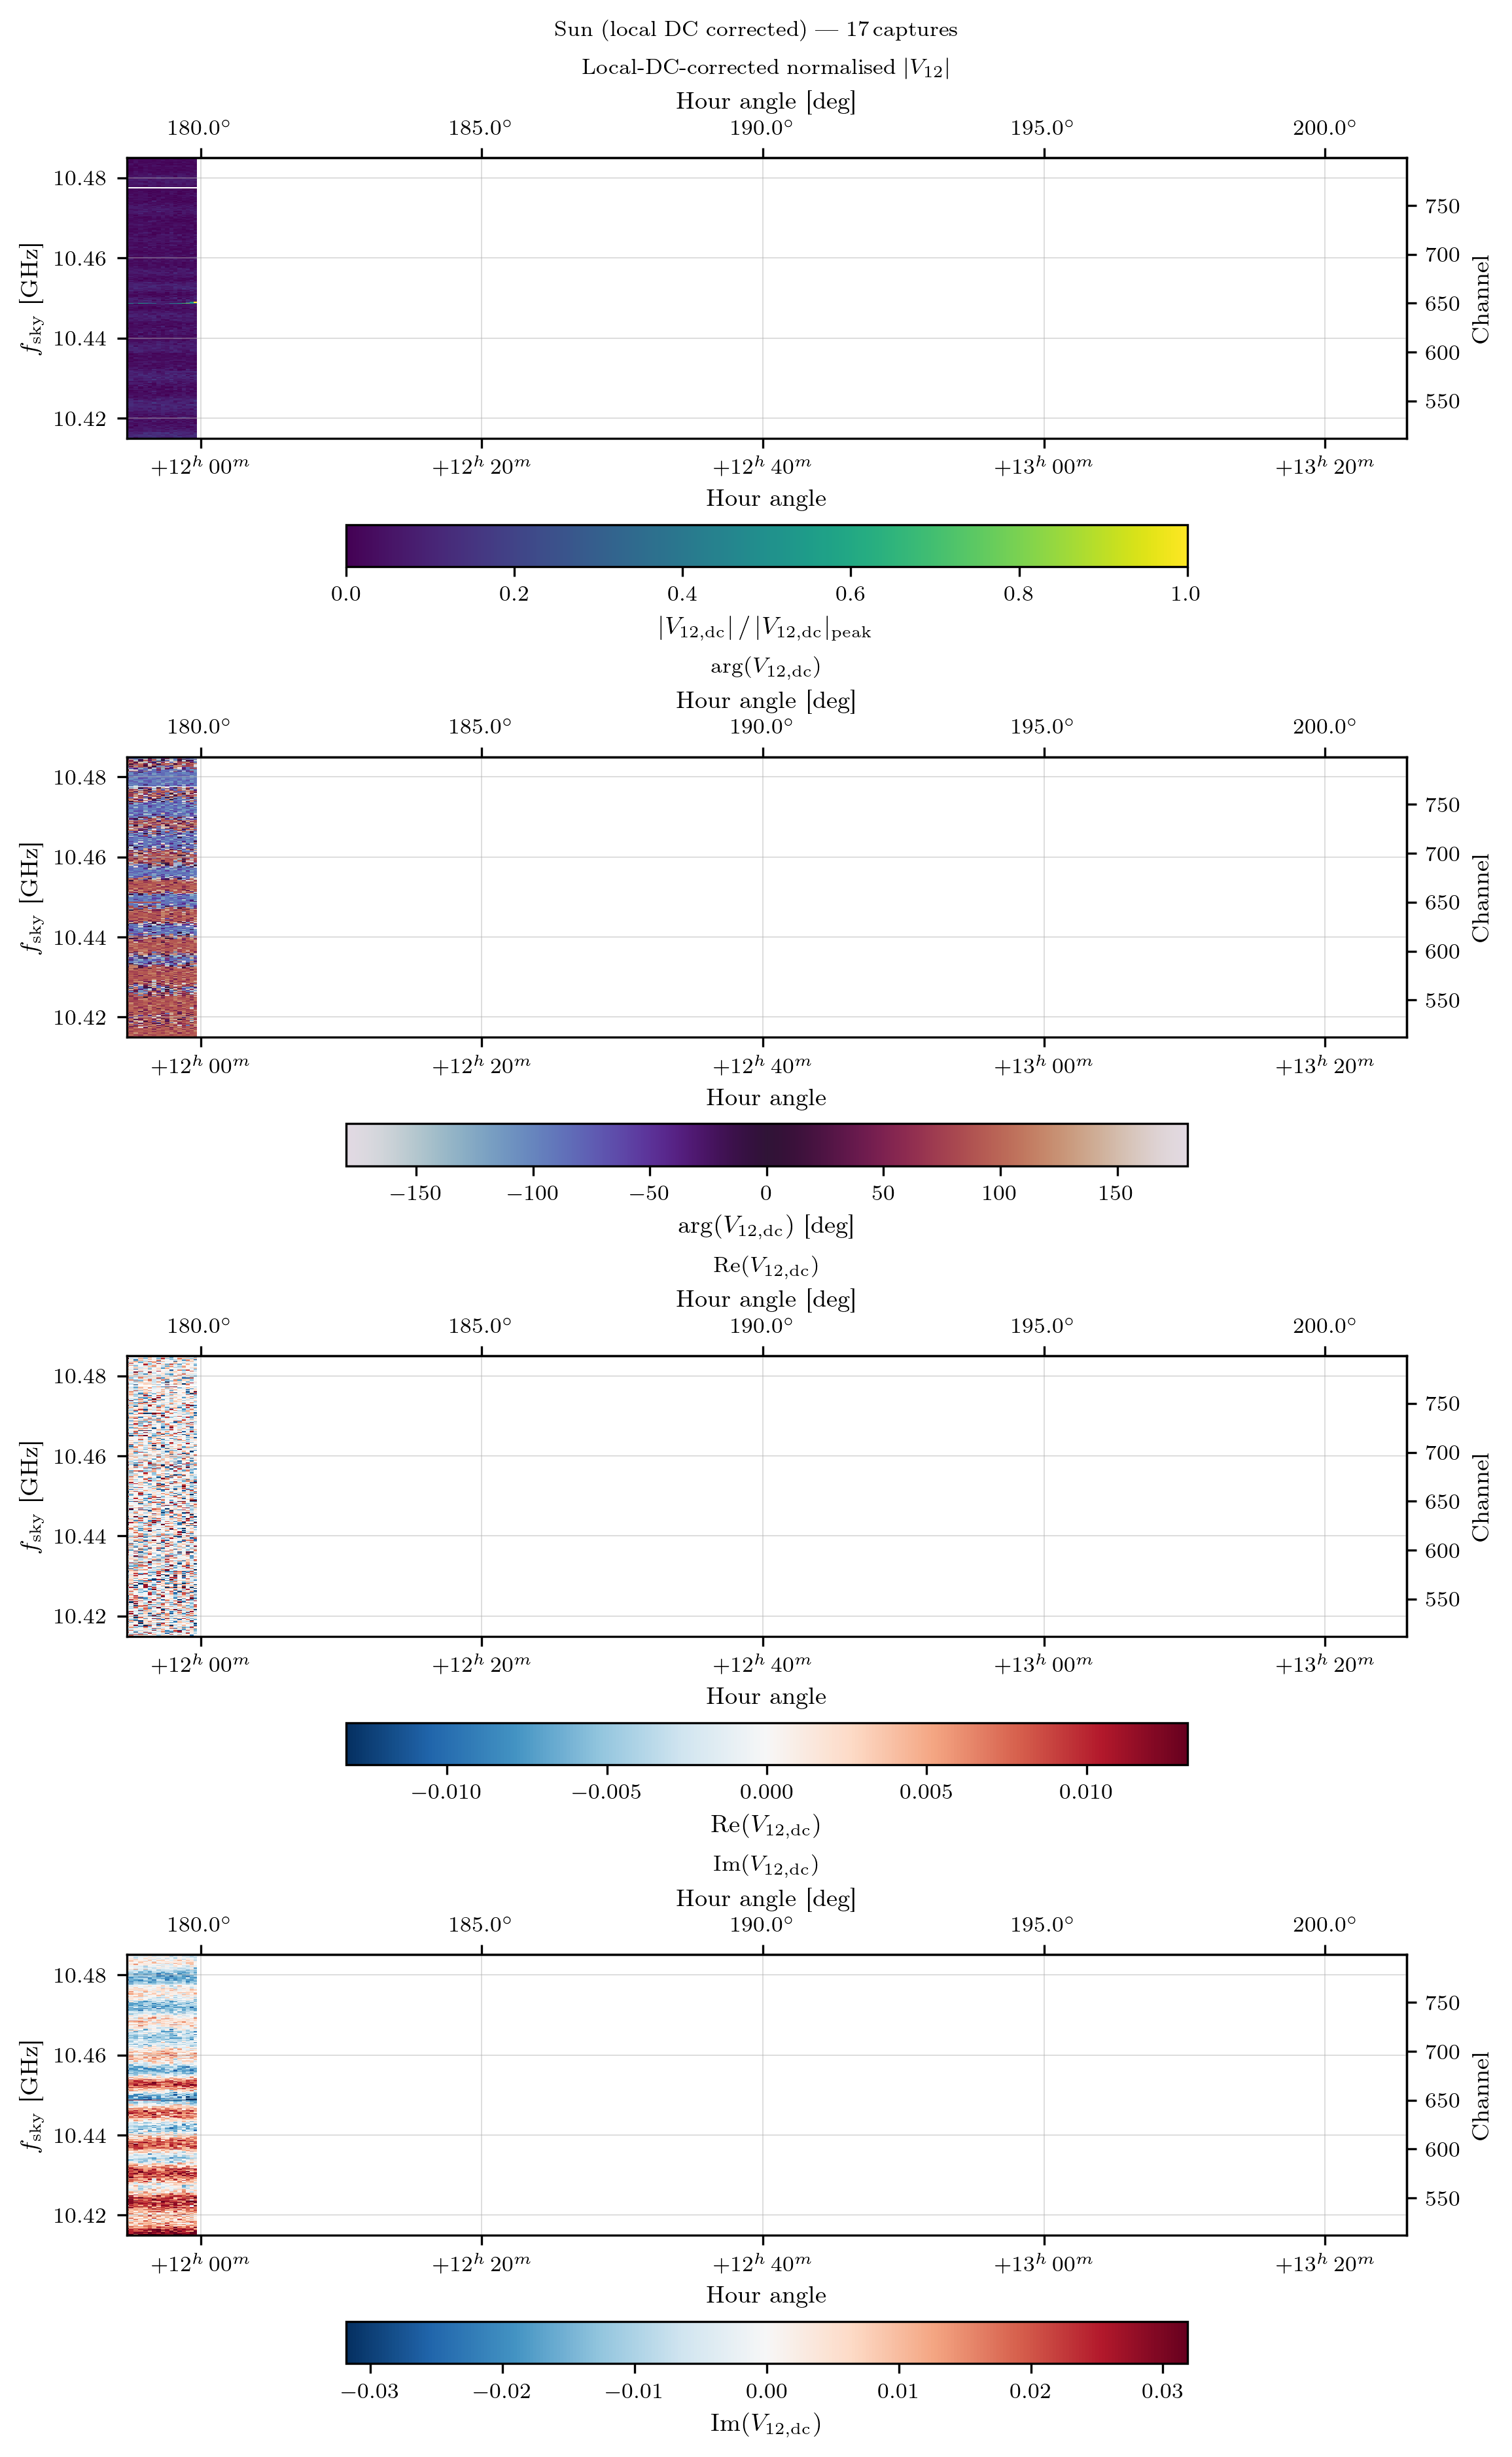

In [8]:
# ---------------------------------------------------------------------------
# Local-DC-corrected waterfalls: normalised amplitude, arg, Re, Im  — f_sky vs hour angle
# ---------------------------------------------------------------------------

amp_dc = np.abs(corr_dc)
amp_dc_peak = np.nanmax(amp_dc)
phase_dc = np.rad2deg(np.angle(corr_dc))
real_dc = corr_dc.real
imag_dc = corr_dc.imag
real_dc_vabs = np.nanpercentile(np.abs(real_dc), 99)
imag_dc_vabs = np.nanpercentile(np.abs(imag_dc), 99)

fig, axes = plot_waterfall_suite(
    f_sky_ghz=F_SKY_GHZ,
    ha_deg=ha_deg,
    quantity_matrices=[amp_dc / amp_dc_peak, phase_dc, real_dc, imag_dc],
    quantity_titles=[
        r'Local-DC-corrected normalised $|V_{12}|$',
        r'$\arg(V_{12,\rm dc})$',
        r'$\mathrm{Re}(V_{12,\rm dc})$',
        r'$\mathrm{Im}(V_{12,\rm dc})$',
    ],
    cbar_labels=[
        r'$|V_{12,\rm dc}|\,/\,|V_{12,\rm dc}|_{\rm peak}$',
        r'$\arg(V_{12,\rm dc})$ [deg]',
        r'$\mathrm{Re}(V_{12,\rm dc})$',
        r'$\mathrm{Im}(V_{12,\rm dc})$',
    ],
    cmap_names=['viridis', 'twilight', 'RdBu_r', 'RdBu_r'],
    vmins=[0, -180, -real_dc_vabs, -imag_dc_vabs],
    vmaxs=[1, 180, real_dc_vabs, imag_dc_vabs],
    plot_band_ghz=PLOT_BAND_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
    title=rf'Sun (local DC corrected) --- {len(files_s)}\,captures',
)
plt.show()


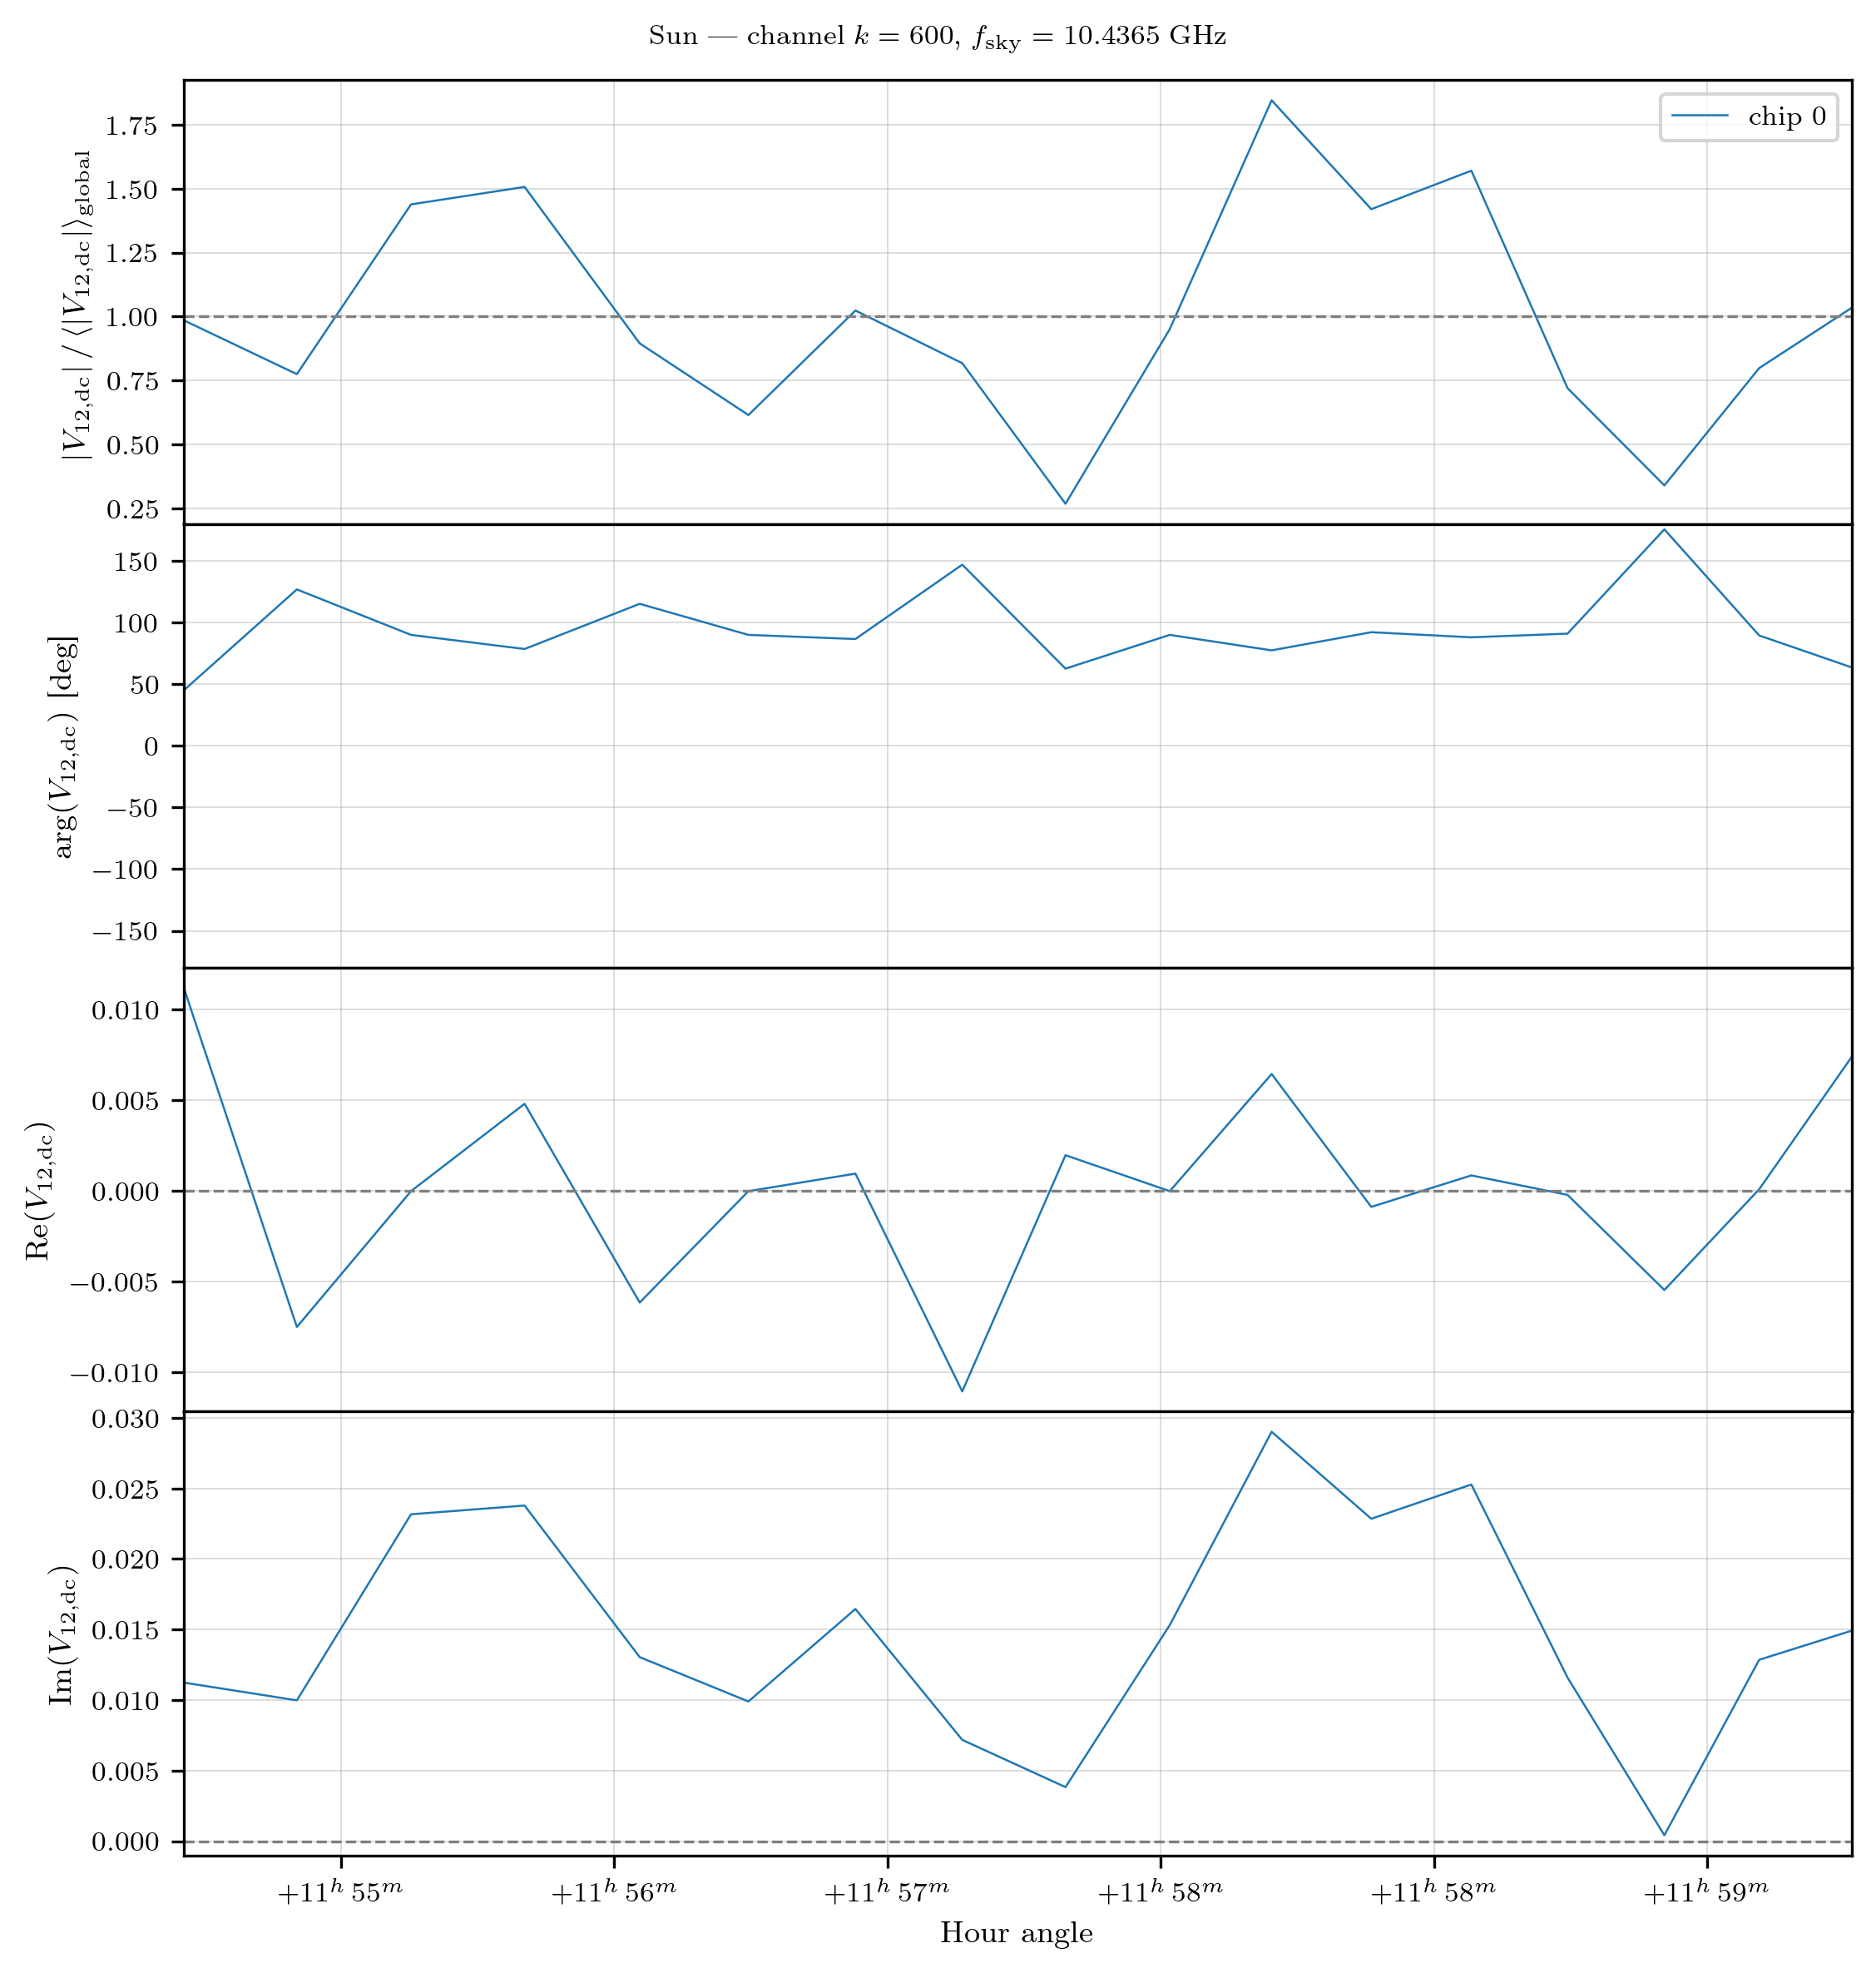

In [9]:
# ---------------------------------------------------------------------------
# Per-channel time series — amplitude, arg, Re, Im vs hour angle
# All chips overlaid on each panel.
# ---------------------------------------------------------------------------

K_CH = 600
_f_ch = F_SKY_GHZ[K_CH]

# Global amplitude mean across all chips for a common normalisation
_amp_global_mean = np.nanmean(
    np.concatenate([np.abs(dc_c[:, K_CH]) for dc_c in corr_dc_chips])
)

_amp_norm_chips = []
_phase_deg_chips = []
_real_chips = []
_imag_chips = []

for dc_c in corr_dc_chips:
    _ch_vis = dc_c[:, K_CH]
    _amp_norm_chips.append(np.abs(_ch_vis) / _amp_global_mean)
    _phase_deg_chips.append(np.rad2deg(np.angle(_ch_vis)))
    _real_chips.append(_ch_vis.real)
    _imag_chips.append(_ch_vis.imag)

fig, axes = plot_channel_time_series(
    ha_chips=ha_chips,
    amp_norm_chips=_amp_norm_chips,
    phase_deg_chips=_phase_deg_chips,
    real_chips=_real_chips,
    imag_chips=_imag_chips,
    channel_index=K_CH,
    channel_freq_ghz=_f_ch,
    ha_limits_deg=(ha_deg.min(), ha_deg.max()),
)
plt.show()


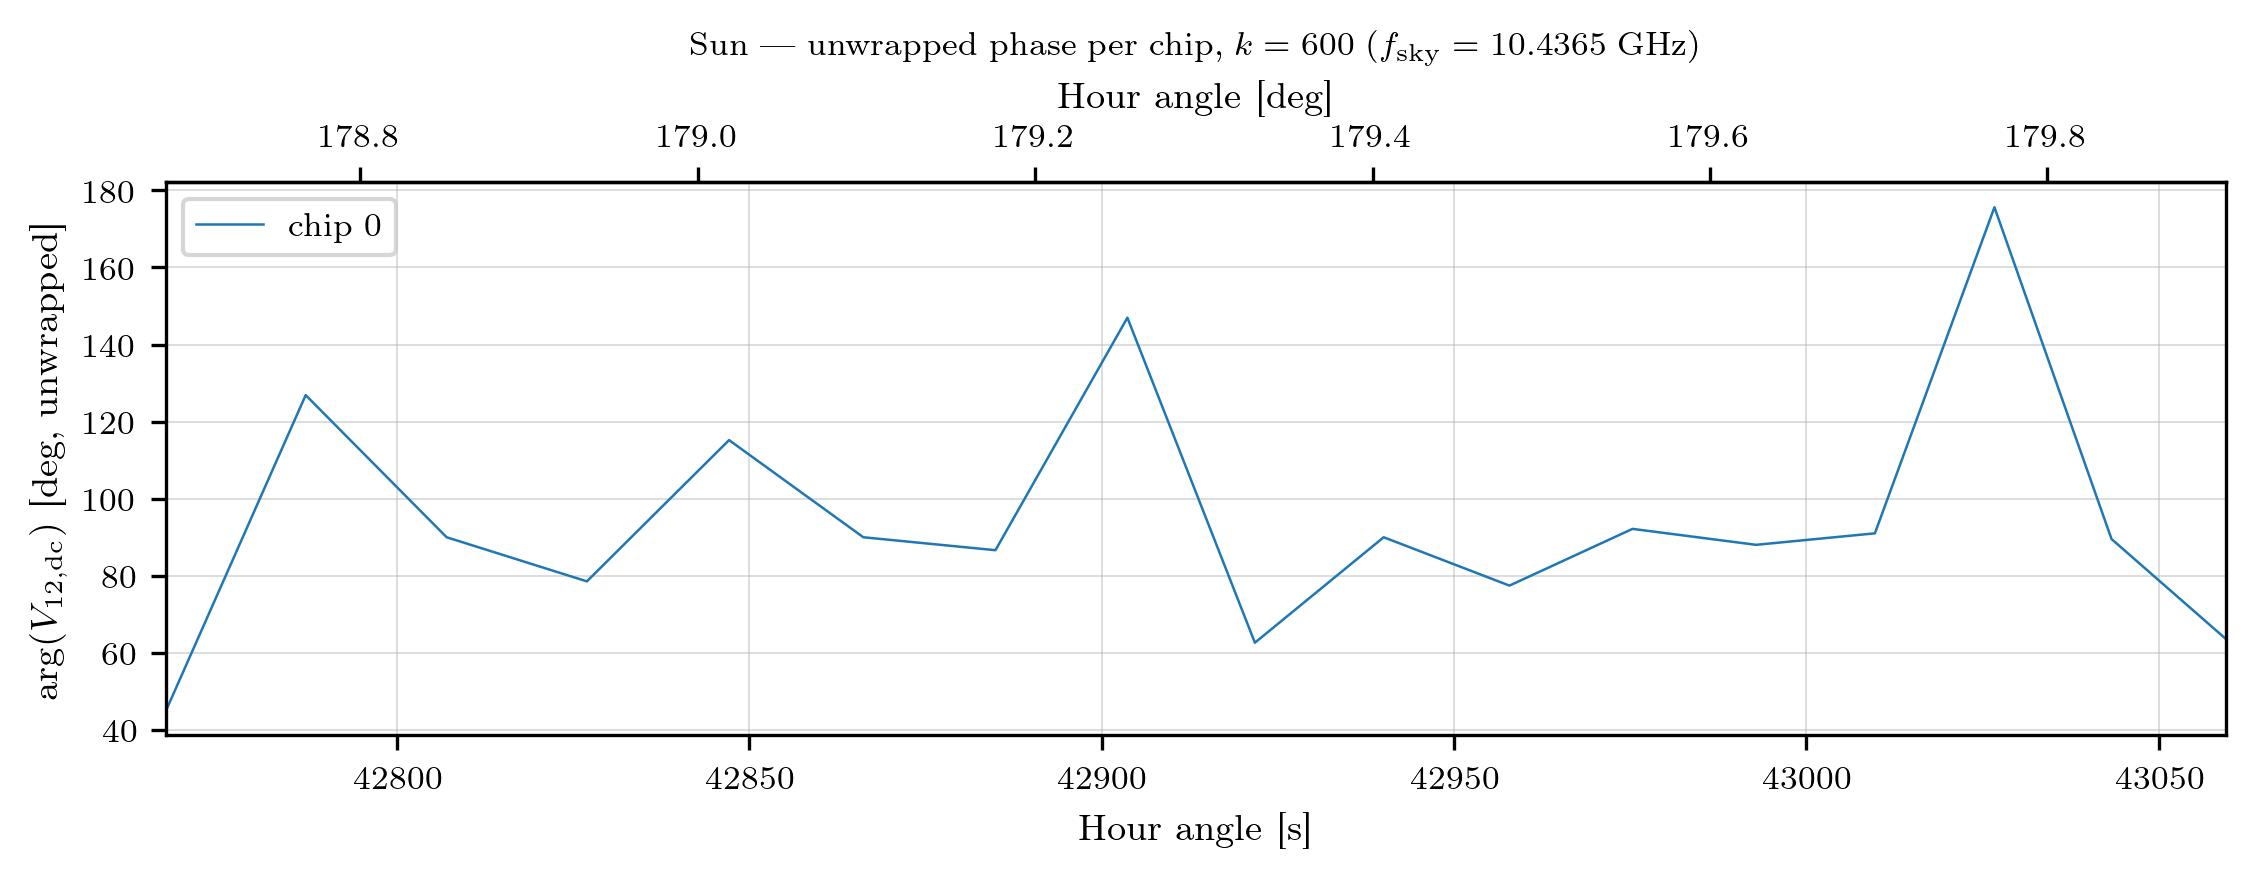

In [10]:
# ---------------------------------------------------------------------------
# Unwrapped phase vs HA-time — channel K_CH
# Unwrap per chip to avoid phase jump at the gap.
# ---------------------------------------------------------------------------

_omega_sid_deg_s = (2 * np.pi / 86164.1) * (180 / np.pi)  # deg/s
_ha_time_s_chips = []
_phase_deg_uw_chips = []

for ha_c, dc_c in zip(ha_chips, corr_dc_chips):
    _ha_time_s_chips.append(ha_c / _omega_sid_deg_s)
    _phase_deg_uw_chips.append(np.degrees(np.unwrap(np.angle(dc_c[:, K_CH]))))

fig, ax = plot_unwrapped_phase_vs_ha_time(
    ha_time_s_chips=_ha_time_s_chips,
    phase_deg_chips=_phase_deg_uw_chips,
    sidereal_rate_deg_s=_omega_sid_deg_s,
    channel_index=K_CH,
    channel_freq_ghz=F_SKY_GHZ[K_CH],
    ha_time_limits_s=(ha_deg.min() / _omega_sid_deg_s, ha_deg.max() / _omega_sid_deg_s),
)
plt.show()
